In [1]:
using Pkg
Pkg.add("Random")
Pkg.add("JuMP")
Pkg.add("Gurobi")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Plots")

using JuMP, Gurobi, CSV, DataFrames

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [2]:
waiting_df = CSV.read("ED_treatment_time.csv", DataFrame)
arrivals_df = CSV.read("ED_arrivals_2.csv", DataFrame)

# Add severity_score column (0 = trivial, 1 = mild, 2 = moderate, 3 = severe, 4 = critical) 
# based on ESI/CTAS–style acuity, expected risk, potential for rapid deterioration, and clinical priority
waiting_df.severity_score = zeros(Int, nrow(waiting_df))

waiting_df.severity_score[1] = 1
waiting_df.severity_score[2] = 3
waiting_df.severity_score[3] = 3
waiting_df.severity_score[4] = 1
waiting_df.severity_score[5] = 1
waiting_df.severity_score[6] = 1
waiting_df.severity_score[7] = 2
waiting_df.severity_score[8] = 4
waiting_df.severity_score[9] = 2
waiting_df.severity_score[10] = 0
waiting_df.severity_score[11] = 1
waiting_df.severity_score[12] = 2
waiting_df.severity_score[13] = 4
waiting_df.severity_score[14] = 4
waiting_df.severity_score[15] = 1
waiting_df.severity_score[16] = 1
waiting_df.severity_score[17] = 1
waiting_df.severity_score[18] = 0
waiting_df.severity_score[19] = 1
waiting_df.severity_score[20] = 2

waiting_df

Row,group,code,name,typical_treatment_time,severity_score
,String7,Int64,String,Float64,Int64
1,Disease,1,"Symptoms, signs, and abnormal clinical and laboratory findings",4.5,1
2,Disease,2,Injury and poisoning,5.0,3
3,Disease,3,Diseases of the respiratory system,8.0,3
4,Disease,4,Diseases of the musculoskeletal system and connective tissue,3.0,1
5,Disease,5,Diseases of the digestive system,1.0,1
6,Disease,6,Diseases of the genitourinary system,3.0,1
7,Disease,7,"Mental, behavioral, and neurodevelopmental disorders",10.0,2
8,Disease,8,Diseases of the circulatory system,6.0,4
9,Disease,9,Certain infectious and parasitic diseases,4.0,2


In [3]:
I = 1:20
T = 24
A = 0:T

# Service time per disease τ_i  we will take from typical_wait_hours
tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)

# Cost per waiting patient g_i  kept at 1 for the first model
g = Dict(i => 1.0 for i in I)

# Fixed capacity per period (e.g., physician-hours per hour)
# Cap[t] = nb_physician * physician_efficacity
Cap = Dict(t => 2000 for t in 1:T)

# Build N as a Dict[(i,t)] from the file
N = Dict((Int(row.disease_index), Int(row.t)) => Int(row.arrivals) for row in eachrow(arrivals_df))

# N[(3, 12)] = arrivals for disease 3 at hour 12

Dict{Tuple{Int64, Int64}, Int64} with 480 entries:
  (11, 17) => 72
  (16, 14) => 72
  (18, 16) => 72
  (17, 12) => 60
  (8, 15)  => 42
  (16, 16) => 72
  (19, 14) => 72
  (7, 18)  => 30
  (7, 8)   => 30
  (14, 15) => 84
  (7, 24)  => 18
  (1, 9)   => 30
  (15, 23) => 36
  (19, 16) => 72
  (2, 17)  => 36
  (10, 17) => 36
  (18, 18) => 60
  (18, 8)  => 60
  (15, 12) => 60
  ⋮        => ⋮

In [4]:
I = 1:20
T = 24
A = 0:T    # max age in queue (in hours)

# Parameters
tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)
s   = Dict(i => waiting_df.severity_score[i] for i in I)   # your severity

Cap = Dict(t => 3000.0 for t in 1:T)

N = Dict((Int(row.disease_index), Int(row.t)) => Float64(row.arrivals)
         for row in eachrow(arrivals_df))

# Age-dependent penalty: c[i,a] = s[i] * a  (or s[i] * (1 + alpha*a))
alpha = 10
c = Dict((i,a) => s[i] * (1.0 + alpha * a) for i in I, a in A)

model = Model(Gurobi.Optimizer)

@variable(model, w[i in I, t in 1:T, a in A] >= 0)
@variable(model, x[i in I, t in 1:T, a in A] >= 0)

# New arrivals at age 0
@constraint(model, [i in I, t in 1:T],
    w[i,t,0] == N[(i,t)]
)

# Optional: initial backlog older than 0 at t = 1 (set to 0 if none)
@constraint(model, [i in I, a in 1:T],
    w[i,1,a] == 0
)

# Queue dynamics
@constraint(model, [i in I, t in 1:T-1, a in 0:T-1],
    w[i, t+1, a+1] == w[i,t,a] - x[i,t,a]
)

# Cannot treat more than waiting
@constraint(model, [i in I, t in 1:T, a in A],
    x[i,t,a] <= w[i,t,a]
)

# Capacity per period
@constraint(model, [t in 1:T],
    sum(tau[i] * x[i,t,a] for i in I, a in A) <= Cap[t]
)

# Objective: severity × age-dependent penalty
@objective(model, Min,
    sum(c[(i,a)] * w[i,t,a] for i in I, t in 1:T, a in A)
)

optimize!(model)

Set parameter Username
Set parameter LicenseID to value 2697101
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 22.1.0 22A380)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 24024 rows, 24000 columns and 70080 nonzeros
Model fingerprint: 0x62d31e33
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 3e+03]
Presolve removed 22311 rows and 18625 columns
Presolve time: 0.02s
Presolved: 1713 rows, 5375 columns, 13475 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 7.950e+03
 Factor NZ  : 1.648e+04 (roughly 2 MB of memory)
 Factor Ops : 2.695e+05 (less than 1 second per iteration)
 Threads    : 1

Barrier performed 0 it

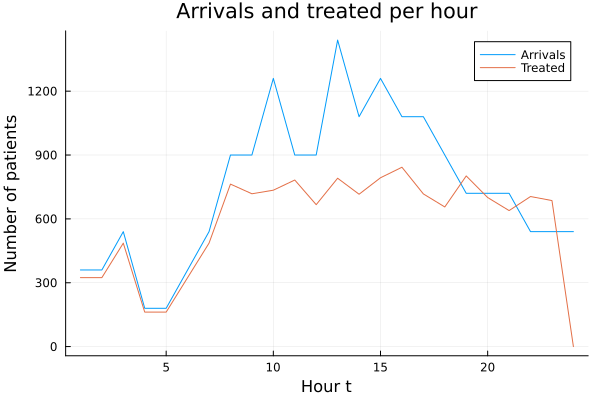

In [5]:
using Plots

# total arrivals per hour (data input)
arrivals_per_t = [sum(N[(i,t)] for i in I) for t in 1:T]

# total treated per hour (model output)
treated_per_t  = [sum(value(x[i,t,a]) for i in I, a in 0:T) for t in 1:T]

plot(1:T, arrivals_per_t,
     label = "Arrivals",
     xlabel = "Hour t",
     ylabel = "Number of patients",
     title = "Arrivals and treated per hour")

plot!(1:T, treated_per_t,
      label = "Treated")


In [13]:
using Plots

# Arrivals per hour from the Dict N
arrivals_per_t = [sum(N[(i,t)] for i in I) for t in 1:T]

# Waiting room count at the start of each hour
waiting_per_t_vec = [value(sum(w[i,t,a] for i in I, a in 1:T)) for t in 1:T]

println("Status: ", termination_status(model))
println("Objective: ", objective_value(model))

# Line plot
plt = plot(1:T, arrivals_per_t,
    label = "Arrivals per hour",
    xlabel = "Hour t",
    ylabel = "Patients",
    title = "Arrivals and waiting room over time",
    legend = :topleft,
    lw = 2,
)
plot!(plt, 1:T, waiting_per_t_vec, label = "Waiting at start", lw = 2)


BoundsError: BoundsError: attempt to access 4-dimensional DenseAxisArray{VariableRef,4,...} with index sets:
    Dimension 1, 1:3
    Dimension 2, 1:20
    Dimension 3, Base.OneTo(24)
    Dimension 4, 0:24
And data, a 3×20×24×25 Array{VariableRef, 4} at index [1, 1, 1]

In [12]:
using Plots

function plot_disease_summary(disease_name::String)
    # Look up the disease index from the arrivals DataFrame
    rows = filter(:disease_name => ==(disease_name), arrivals_df)
    if nrow(rows) == 0
        println("Disease not found: ", disease_name)
        return
    end
    i = unique(rows.disease_index)[1]

    # Compute arrivals per hour for this disease
    arrivals_i = [N[(i,t)] for t in 1:T]

    # Compute queue (sum over all ages) from model results
    queue_i = [value(sum(w[i,t,a] for a in 1:T)) for t in 1:T]

    # Plot side by side "boxes" (bar charts)
    plt1 = bar(1:T, arrivals_i,
        xlabel = "Hour",
        ylabel = "Arrivals",
        title = "Arrivals per hour — $(disease_name)",
        legend = false,
        color = :lightblue,
    )

    plt2 = bar(1:T, queue_i,
        xlabel = "Hour",
        ylabel = "Patients waiting",
        title = "Waiting queue — $(disease_name)",
        legend = false,
        color = :orange,
    )

    # Combine vertically
    plot(plt1, plt2, layout = (2,1), size = (800,600))
end

plot_disease_summary("Diseases of the respiratory system")

# Diseases of the respiratory system


BoundsError: BoundsError: attempt to access 4-dimensional DenseAxisArray{VariableRef,4,...} with index sets:
    Dimension 1, 1:3
    Dimension 2, 1:20
    Dimension 3, Base.OneTo(24)
    Dimension 4, 0:24
And data, a 3×20×24×25 Array{VariableRef, 4} at index [3, 1, 1]

In [33]:
using Random

function generate_scenarios(N::Dict{Tuple{Int,Int},Float64},
                            I::UnitRange{Int},
                            T::Int,
                            waiting_df;
                            num_scenarios::Int = 100,
                            rng = Random.default_rng())

    N_s = Dict{Int, Dict{Tuple{Int,Int},Float64}}()

    # identify respiratory like diseases from names
    respiratory_indices = Int[]
    for i in I
        name = lowercase(String(waiting_df.name[i]))
        occursin("cough", name) ||
        occursin("fever", name) ||
        push!(respiratory_indices, i)
    end

    for s in 1:num_scenarios
        scen = Dict{Tuple{Int,Int},Float64}()

        # choose scenario type
        if s <= round(Int, 0.60 * num_scenarios)
            # normal noise around baseline
            for i in I, t in 1:T
                noise = 0.7 + 0.6 * rand(rng)              # uniform in [0.7, 1.3]
                scen[(i,t)] = N[(i,t)] * noise
            end

        elseif s <= round(Int, 0.85 * num_scenarios)
            # high flow day
            global_factor = 1.2 + 0.4 * rand(rng)         # [1.2, 1.6]
            for i in I, t in 1:T
                factor = global_factor
                noise = 0.9 + 0.2 * rand(rng)             # [0.9, 1.1]
                scen[(i,t)] = N[(i,t)] * factor * noise
            end

        else
            # epidemic scenario
            resp_boost  = 2.0 + 2.0 * rand(rng)           # [2.0, 4.0]
            other_factor = 0.8 + 0.4 * rand(rng)          # [0.8, 1.2]

            for i in I, t in 1:T
                factor = other_factor
                if i in respiratory_indices
                    factor = resp_boost
                    factor *= 1.1 + 0.4 * rand(rng) 
                end
                noise = 0.9 + 0.3 * rand(rng)             # [0.9, 1.2]
                scen[(i,t)] = N[(i,t)] * factor * noise
            end
        end

        N_s[s] = scen
    end

    # scenario probabilities (uniform for now)
    p = Dict(s => 1.0 / num_scenarios for s in 1:num_scenarios)

    return N_s, p
end


generate_scenarios (generic function with 1 method)

In [35]:
# baseline N, I, T already defined
Random.seed!(1234)  # for reproducibility, optional

num_scenarios = 100
N_s, p = generate_scenarios(N, I, T, waiting_df; num_scenarios = num_scenarios)

S = 1:num_scenarios

model = Model(Gurobi.Optimizer)

A = 0:T

tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)
s   = Dict(i => waiting_df.severity_score[i] for i in I)
alpha = 10.0
c = Dict((i,a) => s[i] * (1.0 + alpha * a) for i in I, a in A)

Cap = Dict(t => 3000.0 for t in 1:T)

@variable(model, w[s in S, i in I, t in 1:T, a in A] >= 0)
@variable(model, x[s in S, i in I, t in 1:T, a in A] >= 0)

@constraint(model, [s in S, i in I, t in 1:T], w[s,i,t,0] == N_s[s][(i,t)])
@constraint(model, [s in S, i in I, a in 1:T], w[s,i,1,a] == 0)
@constraint(model, [s in S, i in I, t in 1:T-1, a in 0:T-1],w[s,i,t+1,a+1] == w[s,i,t,a] - x[s,i,t,a])

@constraint(model, [s in S, i in I, t in 1:T, a in A], x[s,i,t,a] <= w[s,i,t,a])

@constraint(model, [s in S, t in 1:T], sum(tau[i] * x[s,i,t,a] for i in I, a in A) <= Cap[t])

@objective(model, Min, sum(p[s] * sum(c[(i,a)] * w[s,i,t,a] for i in I, t in 1:T, a in A) for s in S))

optimize!(model)


Set parameter Username
Set parameter LicenseID to value 2697101
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 22.1.0 22A380)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2402400 rows, 2400000 columns and 7008000 nonzeros
Model fingerprint: 0xcef4e44a
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e-02, 1e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 3e+03]
Presolve removed 2231045 rows and 1861855 columns
Presolve time: 1.92s
Presolved: 171355 rows, 538145 columns, 1349855 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.18s

Barrier statistics:
 AA' NZ     : 9.973e+05
 Factor NZ  : 2.123e+06 (roughly 300 MB of memory)
 Factor Ops : 3.415e+07 (less than 1 second per iteration)
 Threads    : 6

    

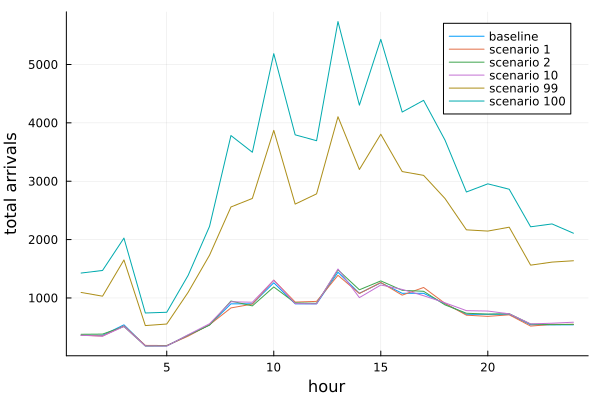

In [38]:
using Plots

times = collect(1:T)

# baseline
arrivals_base = [sum(N[(i,t)] for i in I) for t in 1:T]

# helper
function total_arrivals_scenario(s)
    [sum(N_s[s][(i,t)] for i in I) for t in 1:T]
end

scens_to_plot = [1, 2, 10, 99, 100] 

pltN = plot(times, arrivals_base,
    label = "baseline",
    xlabel = "hour",
    ylabel = "total arrivals"
)

for s_id in scens_to_plot
    plot!(pltN, times, total_arrivals_scenario(s_id),
        label = "scenario $(s_id)")
end

display(pltN)


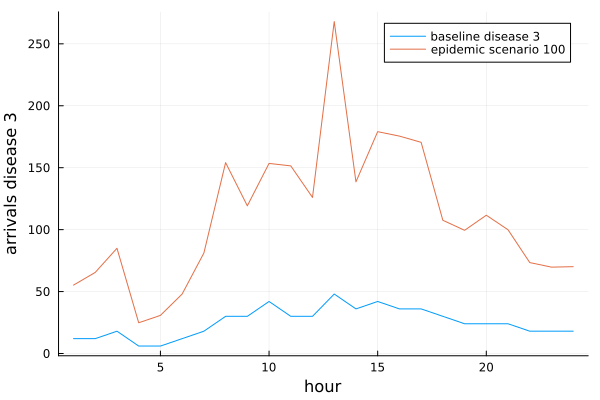

In [39]:
i0 = 3  # choose a respiratory disease index

arrivals_base_i0 = [N[(i0,t)] for t in 1:T]

# find a scenario that is epidemic, say the last one
epi_s = num_scenarios  # if your generator makes late scenarios epidemic
arrivals_epi_i0 = [N_s[epi_s][(i0,t)] for t in 1:T]

pltDisease = plot(times, arrivals_base_i0,
    label = "baseline disease $(i0)",
    xlabel = "hour",
    ylabel = "arrivals disease $(i0)"
)
plot!(pltDisease, times, arrivals_epi_i0,
    label = "epidemic scenario $(epi_s)")

display(pltDisease)


In [ ]:
scenario_cost = Dict{Int, Float64}()

for s_id in S
    scenario_cost[s_id] = sum(
        c[(i,a)] * value(w[s_id, i, t, a])
        for i in I, t in 1:T, a in A
    )
end

# simple scatter or line over scenarios
pltCost = plot(collect(S), [scenario_cost[s] for s in S],
    seriestype = :scatter,
    xlabel = "scenario",
    ylabel = "total severity weighted waiting",
    label = "cost per scenario"
)
display(pltCost)

# histogram of costs
pltCostHist = histogram([scenario_cost[s] for s in S],
    bins = 20,
    xlabel = "total severity weighted waiting",
    ylabel = "count of scenarios",
    label = "scenario costs"
)
display(pltCostHist)


In [ ]:
# S = 1:3  # three scenarios
# p = Dict(s => 1.0 / length(S) for s in S)  # scenario probabilities
# N_s = Dict{Int, Dict{Tuple{Int,Int}, Float64}}()

# # fill N_s[s] dictionaries with stress patterns
# N_s[1] = N
# N_s[2] = Dict((i,t) => 1.2 * N[(i,t)] for i in I, t in 1:T)
# N_s[3] = Dict((i,t) => (t in 18:24 ? 1.5 * N[(i,t)] : N[(i,t)]) for i in I, t in 1:T) # more arrival than expected during the night

# model = Model(Gurobi.Optimizer)

# I = 1:20
# T = 24
# A = 0:T
# S = 1:3

# tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)
# s   = Dict(i => waiting_df.severity_score[i] for i in I)
# alpha = 10.0
# c = Dict((i,a) => s[i] * (1.0 + alpha * a) for i in I, a in A)

# Cap = Dict(t => 3000.0 for t in 1:T)

# # scenario dependent w and x
# @variable(model, w[s in S, i in I, t in 1:T, a in A] >= 0)
# @variable(model, x[s in S, i in I, t in 1:T, a in A] >= 0)

# # arrivals per scenario
# @constraint(model, [s in S, i in I, t in 1:T], w[s,i,t,0] == N_s[s][(i,t)])

# @constraint(model, [s in S, i in I, a in 1:T], w[s,i,1,a] == 0)

# @constraint(model, [s in S, i in I, t in 1:T-1, a in 0:T-1], w[s,i,t+1,a+1] == w[s,i,t,a] - x[s,i,t,a])

# @constraint(model, [s in S, i in I, t in 1:T, a in A], x[s,i,t,a] <= w[s,i,t,a])

# @constraint(model, [s in S, t in 1:T], sum(tau[i] * x[s,i,t,a] for i in I, a in A) <= Cap[t])



# # Choose objective type:
# # 1) minimize expected cost across scenarios
# @objective(model, Min, sum(p[s] * sum(c[(i,a)] * w[s,i,t,a] for i in I, t in 1:T, a in A) for s in S))

# # If you want worst case robust instead, change to
# # @objective(model, Min, maximum over scenarios)
# # which you linearize by an auxiliary variable:

# # @variable(model, θ)
# # @constraint(model, [s in S],
# #     θ >= sum(c[(i,a)] * w[s,i,t,a] for i in I, t in 1:T, a in A)
# # )
# # @objective(model, Min, θ)

# optimize!(model)


Set parameter Username
Set parameter LicenseID to value 2697101
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 22.1.0 22A380)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 72072 rows, 72000 columns and 210240 nonzeros
Model fingerprint: 0x4e5f72bf
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [3e-01, 3e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 3e+03]
Presolve removed 66932 rows and 55857 columns
Presolve time: 0.05s
Presolved: 5140 rows, 16143 columns, 40479 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 AA' NZ     : 2.391e+04
 Factor NZ  : 5.016e+04 (roughly 7 MB of memory)
 Factor Ops : 8.265e+05 (less than 1 second per iteration)
 Threads    : 1

Barrier performed 0 

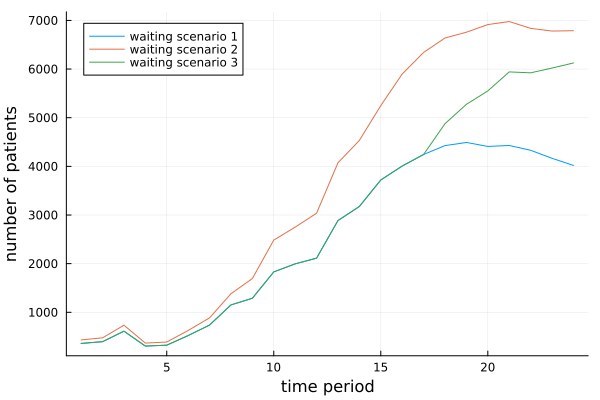

In [ ]:
# # Total queue size per scenario and time

# times = collect(1:T)


# waiting_total = Dict{Int, Vector{Float64}}()
# for ss in S
#     waiting_total[ss] = [sum(value(w[ss, i, t, a]) for i in I, a in A) for t in 1:T]
# end

# plt2 = plot(xlabel = "time period", ylabel = "number of patients")
# for ss in S
#     plot!(plt2, times, waiting_total[ss], label = "waiting scenario $(ss)")
# end

# display(plt2)

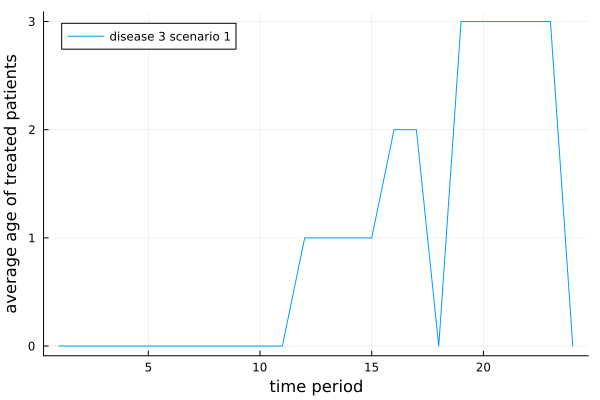

In [20]:
i0 = 3  # choose a disease index

# average age of treated patients at each time for scenario 1
avg_age_treated = Float64[]
for t in 1:T
    num = sum(a * value(x[1, i0, t, a]) for a in A)
    den = sum(value(x[1, i0, t, a]) for a in A)
    push!(avg_age_treated, den > 0 ? num / den : 0.0)
end

plt4 = plot(times, avg_age_treated,
    xlabel = "time period",
    ylabel = "average age of treated patients",
    label = "disease $(i0) scenario 1"
)
display(plt4)
